### Versión 1

In [ ]:
import sys
sys.path.append("..")

import os
import inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import simpson
from scipy.optimize import least_squares
from cryoevap.storage_tanks import Tank
from cryoevap.cryogens import Cryogen

Tank utilizado: c:\Users\fabia\IPRE\CryoEvap\notebooks\..\cryoevap\storage_tanks\tank.py


In [2]:
excel_path = os.path.join("..", "data", "Data_wang_merida.xlsx")
wm_sheets = pd.read_excel(excel_path, sheet_name=None)

def prepare_experimental_curve(dataframe, time_column, value_column, time_min_h=0.0, time_max_h=None):
    curve = dataframe[[time_column, value_column]].copy()
    curve.columns = ["time_h", "value"]
    curve["time_h"] = pd.to_numeric(curve["time_h"], errors="coerce")
    curve["value"] = pd.to_numeric(curve["value"], errors="coerce")
    curve = curve.dropna(subset=["time_h", "value"])
    curve = curve[curve["time_h"] >= time_min_h]
    if time_max_h is not None:
        curve = curve[curve["time_h"] <= time_max_h]
    curve = curve.sort_values("time_h")
    curve = curve.groupby("time_h", as_index=False).mean()
    curve = curve.reset_index(drop=True)
    if curve.empty:
        raise ValueError("La curva experimental quedó vacía.")
    return curve

Tv_vertical_exp = prepare_experimental_curve(wm_sheets["12a_T"], "t_Tv_vert_h", "Tv_vert_K", 0.0, 5.0)
BOG_vertical_exp = prepare_experimental_curve(wm_sheets["12e_BOG"], "t_vert_h", "BOG_vert_kg_h", 0.0, 5.0)

print("Datos de temperatura:", len(Tv_vertical_exp))
print("Rango temporal temperatura:", Tv_vertical_exp["time_h"].min(), Tv_vertical_exp["time_h"].max())
print("Datos de BOG:", len(BOG_vertical_exp))
print("Rango temporal BOG:", BOG_vertical_exp["time_h"].min(), BOG_vertical_exp["time_h"].max())

display(Tv_vertical_exp.head())
display(BOG_vertical_exp.head())

Datos de temperatura: 5
Rango temporal temperatura: 0.16722408026755176 4.515050167224068
Datos de BOG: 8
Rango temporal BOG: 0.1517876067470212 3.3909488092877638


,time_h,value
0,0.167224,20.666669
1,0.501672,20.813092
2,1.337793,20.943946
3,2.173913,21.049878
4,4.515050,21.109105


,time_h,value
0,0.151788,0.182904
1,0.307165,0.170134
2,0.625098,0.153243
3,0.945083,0.138825
4,1.265068,0.124407


In [3]:
from copy import deepcopy

P = 101_300.0
V_tank = 4.89
d_i = 1.676
d_o = d_i
LF_initial = 0.30
q_initial = 0.50
T_air_fixed = 288.15
eta_w_initial = 0.97

simulation_config = {"t_f": 5 * 3600, "dz": 0.01, "time_interval": 60}
parameters_to_fit = ["U", "eta_w"]
observables = ["Tv_avg", "BOG"]

hydrogen_base = Cryogen(name="hydrogen")
hydrogen_base.set_coolprops(P)

U_initial = q_initial / (T_air_fixed - hydrogen_base.T_sat)
theta_initial = np.array([U_initial, eta_w_initial], dtype=float)

base_tank = Tank(d_i=d_i, d_o=d_o, V=V_tank, vapour_geometry="cylindrical", liquid_geometry="cylindrical", LF=LF_initial, head_type="flat")
base_tank.cryogen = hydrogen_base
base_tank.set_HeatTransProps(U_L=U_initial, U_V=U_initial, T_air=T_air_fixed, Q_b_fixed=None, Q_roof=0.0, eta_w=eta_w_initial)

print("Configuración base:")
print(f"T_sat                  = {base_tank.cryogen.T_sat:.10f} K")
print(f"T_air fija             = {T_air_fixed:.10f} K")
print(f"U inicial              = {U_initial:.12f} W/(m² K)")
print(f"eta_w inicial          = {eta_w_initial:.6f}")
print(f"Tiempo de simulación   = {simulation_config['t_f']/3600:.2f} h")
print(f"dz objetivo            = {simulation_config['dz']:.4f} m")
print(f"Intervalo de salida    = {simulation_config['time_interval']} s")
print(f"Parámetros             = {parameters_to_fit}")
print(f"Observables            = {observables}")
print(f"Tanque aún no simulado = {base_tank.sol is None}")

assert base_tank.sol is None
assert 0.0 < eta_w_initial < 1.0
assert U_initial > 0.0

Configuración base:
T_sat                  = 20.3680675984 K
T_air fija             = 288.1500000000 K
U inicial              = 0.001867190947 W/(m² K)
eta_w inicial          = 0.970000
Tiempo de simulación   = 5.00 h
dz objetivo            = 0.0100 m
Intervalo de salida    = 60 s
Parámetros             = ['U', 'eta_w']
Observables            = ['Tv_avg', 'BOG']
Tanque aún no simulado = True


In [4]:
def simulate(theta):
    theta = np.asarray(theta, dtype=float)

    if theta.shape != (2,):
        raise ValueError("theta debe contener exactamente [U, eta_w].")

    if not np.all(np.isfinite(theta)):
        raise ValueError("theta contiene valores no finitos.")

    U = theta[0]
    eta_w = theta[1]

    if U <= 0.0:
        raise ValueError("U debe ser positivo.")

    if not 0.0 <= eta_w <= 1.0:
        raise ValueError("eta_w debe estar entre 0 y 1.")

    tank = deepcopy(base_tank)

    tank.set_HeatTransProps(U_L=U, U_V=U, T_air=T_air_fixed, Q_b_fixed=None, Q_roof=0.0, eta_w=eta_w)

    n_z = max(3, 1 + int(np.round(tank.l_V / simulation_config["dz"])))

    tank.z_grid = np.linspace(0.0, 1.0, n_z)
    tank.time_interval = simulation_config["time_interval"]

    tank.evaporate(simulation_config["t_f"])

    if not tank.sol.success:
        raise RuntimeError(f"La simulación falló: {tank.sol.message}")

    results = pd.DataFrame()
    results["time_h"] = tank.sol.t / 3600.0
    results["Tv_avg_K"] = np.asarray(tank.data["Tv_avg"])
    results["BOG_kg_h"] = np.asarray(tank.data["BOG"]) * 3600.0
    results["LF"] = np.asarray(tank.data["LF"])

    if not np.all(np.isfinite(results.to_numpy())):
        raise ValueError("La simulación produjo valores no finitos.")

    return tank, results

In [ ]:
# test 1
tank_initial, model_initial = simulate(theta_initial)

print("Simulación inicial:")
print(f"Solver exitoso             = {tank_initial.sol.success}")
print(f"Número de nodos            = {len(tank_initial.z_grid)}")
print(f"Número de tiempos          = {len(model_initial)}")
print(f"Tiempo final               = {model_initial['time_h'].iloc[-1]:.6f} h")
print(f"Tv_avg final               = {model_initial['Tv_avg_K'].iloc[-1]:.10f} K")
print(f"BOG final                  = {model_initial['BOG_kg_h'].iloc[-1]:.10f} kg/h")
print(f"LF final                   = {model_initial['LF'].iloc[-1]:.10f}")
print(f"Tanque base sin simular    = {base_tank.sol is None}")

display(model_initial.head())

Simulación inicial:
Solver exitoso             = True
Número de nodos            = 156
Número de tiempos          = 301
Tiempo final               = 5.000000 h
Tv_avg final               = 20.4091872076 K
BOG final                  = 0.0642479134 kg/h
LF final                   = 0.2990862410
Tanque base sin simular    = True


,time_h,Tv_avg_K,BOG_kg_h,LF
0,0.000000,20.368078,0.063267,0.300000
1,0.016667,20.368237,0.064823,0.299997
2,0.033333,20.368395,0.064813,0.299994
3,0.050000,20.368552,0.064811,0.299991
4,0.066667,20.368709,0.064800,0.299988


#### Interpolación

Ajuste de puntos de la curva a los datos experimentales

In [6]:
def interpolate_model_to_experiment(experimental_curve, model_results, model_column):
    x_exp = np.asarray(experimental_curve["time_h"], dtype=float)
    x_model = np.asarray(model_results["time_h"], dtype=float)
    y_model = np.asarray(model_results[model_column], dtype=float)

    if x_exp.ndim != 1 or x_model.ndim != 1 or y_model.ndim != 1:
        raise ValueError("Las entradas de interpolación deben ser unidimensionales.")

    if len(x_model) != len(y_model):
        raise ValueError("Los tiempos y valores del modelo deben tener igual longitud.")

    if len(x_model) < 2:
        raise ValueError("Se necesitan al menos dos puntos del modelo.")

    if not np.all(np.isfinite(x_exp)) or not np.all(np.isfinite(x_model)) or not np.all(np.isfinite(y_model)):
        raise ValueError("La interpolación recibió valores no finitos.")

    if not np.all(np.diff(x_model) > 0.0):
        raise ValueError("Los tiempos del modelo deben ser estrictamente crecientes.")

    if np.min(x_exp) < np.min(x_model):
        raise ValueError("Existen datos experimentales anteriores al inicio del modelo.")

    if np.max(x_exp) > np.max(x_model):
        raise ValueError("Existen datos experimentales posteriores al final del modelo.")

    y_interpolated = np.interp(x_exp, x_model, y_model)

    return y_interpolated

In [ ]:
# Test 2
Tv_model_interpolated = interpolate_model_to_experiment(Tv_vertical_exp, model_initial, "Tv_avg_K")
BOG_model_interpolated = interpolate_model_to_experiment(BOG_vertical_exp, model_initial, "BOG_kg_h")

Tv_comparison = pd.DataFrame({"time_h": Tv_vertical_exp["time_h"], "experimental_K": Tv_vertical_exp["value"], "model_K": Tv_model_interpolated})
BOG_comparison = pd.DataFrame({"time_h": BOG_vertical_exp["time_h"], "experimental_kg_h": BOG_vertical_exp["value"], "model_kg_h": BOG_model_interpolated})

print("Comparación de temperatura:")
display(Tv_comparison)

print("Comparación de BOG:")
display(BOG_comparison)

print("Interpolación de temperatura finita:", np.all(np.isfinite(Tv_model_interpolated)))
print("Interpolación de BOG finita:", np.all(np.isfinite(BOG_model_interpolated)))

Comparación de temperatura:


,time_h,experimental_K,model_K
0,0.167224,20.666669,20.369640
1,0.501672,20.813092,20.372668
2,1.337793,20.943946,20.379950
3,2.173913,21.049878,20.386949
4,4.515050,21.109105,20.405501


Comparación de BOG:


,time_h,experimental_kg_h,model_kg_h
0,0.151788,0.182904,0.064747
1,0.307165,0.170134,0.064720
2,0.625098,0.153243,0.064682
3,0.945083,0.138825,0.064620
4,1.265068,0.124407,0.064569
5,2.075114,0.100513,0.064540
6,2.731151,0.091037,0.064442
7,3.390949,0.086093,0.064424


Interpolación de temperatura finita: True
Interpolación de BOG finita: True


#### Factores de escala

Necesitamos normalizar

In [8]:
def calculate_scale(values, method="std"):
    values = np.asarray(values, dtype=float)

    if values.ndim != 1:
        raise ValueError("Los valores deben formar un arreglo unidimensional.")

    if len(values) == 0:
        raise ValueError("No se puede calcular una escala con un arreglo vacío.")

    if not np.all(np.isfinite(values)):
        raise ValueError("Los valores contienen NaN o infinitos.")

    if method == "std":
        scale = np.std(values)

    elif method == "max":
        scale = np.max(np.abs(values))

    elif method == "mean":
        scale = np.mean(np.abs(values))

    elif method == "one":
        scale = 1.0

    else:
        raise ValueError("method debe ser 'std', 'max', 'mean' o 'one'.")

    if not np.isfinite(scale) or scale <= 1e-12:
        scale = 1.0

    return float(scale)

In [10]:
scale_method = "std"

scale_Tv = calculate_scale(Tv_vertical_exp["value"], method=scale_method)
scale_BOG = calculate_scale(BOG_vertical_exp["value"], method=scale_method)

scales = {"Tv_avg": scale_Tv, "BOG": scale_BOG}

print("Factores de escala:")
print(f"Método                     = {scale_method}")
print(f"Escala de Tv_avg           = {scale_Tv:.12f} K")
print(f"Escala de BOG              = {scale_BOG:.12f} kg/h")

Factores de escala:
Método                     = std
Escala de Tv_avg           = 0.160466912296 K
Escala de BOG              = 0.034219780169 kg/h


#### Función de residuos normalizados

In [11]:
def calculate_residuals_from_results(model_results):
    Tv_model = interpolate_model_to_experiment(Tv_vertical_exp, model_results, "Tv_avg_K")
    BOG_model = interpolate_model_to_experiment(BOG_vertical_exp, model_results, "BOG_kg_h")

    Tv_exp = np.asarray(Tv_vertical_exp["value"], dtype=float)
    BOG_exp = np.asarray(BOG_vertical_exp["value"], dtype=float)

    residuals_Tv = (Tv_model - Tv_exp) / scales["Tv_avg"]
    residuals_BOG = (BOG_model - BOG_exp) / scales["BOG"]

    weighted_residuals_Tv = residuals_Tv / np.sqrt(len(residuals_Tv))
    weighted_residuals_BOG = residuals_BOG / np.sqrt(len(residuals_BOG))

    residual_vector = np.concatenate([weighted_residuals_Tv, weighted_residuals_BOG])

    details = {"Tv_model": Tv_model, "BOG_model": BOG_model, "residuals_Tv": residuals_Tv, "residuals_BOG": residuals_BOG}

    return residual_vector, details

In [12]:
residual_vector_initial, residual_details_initial = calculate_residuals_from_results(model_initial)

objective_Tv_initial = np.mean(residual_details_initial["residuals_Tv"]**2)
objective_BOG_initial = np.mean(residual_details_initial["residuals_BOG"]**2)
objective_total_initial = np.sum(residual_vector_initial**2)

print("Función objetivo basal:")
print(f"Aporte de Tv_avg          = {objective_Tv_initial:.10f}")
print(f"Aporte de BOG             = {objective_BOG_initial:.10f}")
print(f"Objetivo total            = {objective_total_initial:.10f}")
print(f"Suma de aportes           = {(objective_Tv_initial + objective_BOG_initial):.10f}")
print(f"Número total de residuos  = {len(residual_vector_initial)}")
print(f"Todos los residuos finitos = {np.all(np.isfinite(residual_vector_initial))}")

print("\nResiduos normalizados de temperatura:")
print(residual_details_initial["residuals_Tv"])

print("\nResiduos normalizados de BOG:")
print(residual_details_initial["residuals_BOG"])

Función objetivo basal:
Aporte de Tv_avg          = 11.9211291121
Aporte de BOG             = 4.7474647466
Objetivo total            = 16.6685938587
Suma de aportes           = 16.6685938587
Número total de residuos  = 13
Todos los residuos finitos = True

Residuos normalizados de temperatura:
[-1.8510324  -2.74464277 -3.51471782 -4.13124823 -4.38472432]

Residuos normalizados de BOG:
[-3.45288004 -3.08048426 -2.58800847 -2.16848954 -1.74863524 -1.05123084
 -0.77719291 -0.63322911]


#### Vector completo de residuos y valor $J$

In [13]:
def residuals_theta(theta):
    tank, model_results = simulate(theta)
    residual_vector, residual_details = calculate_residuals_from_results(model_results)

    return residual_vector

In [14]:
def objective(theta):
    residual_vector = residuals_theta(theta)
    objective_value = np.sum(residual_vector**2)

    return float(objective_value)

In [15]:
# Test 4
objective_from_theta = objective(theta_initial)
objective_difference = abs(objective_from_theta - objective_total_initial)

print("Comprobación de objective(theta):")
print(f"Objetivo calculado previamente = {objective_total_initial:.12f}")
print(f"Objetivo desde theta           = {objective_from_theta:.12f}")
print(f"Diferencia                     = {objective_difference:.3e}")
print(f"Coincidencia                   = {np.isclose(objective_from_theta, objective_total_initial, rtol=1e-10, atol=1e-10)}")
print(f"Tanque base sin simular        = {base_tank.sol is None}")

Comprobación de objective(theta):
Objetivo calculado previamente = 16.668593858712
Objetivo desde theta           = 16.668593858712
Diferencia                     = 0.000e+00
Coincidencia                   = True
Tanque base sin simular        = True


In [16]:
Test 4.1
theta_eta_test = np.array([U_initial, 0.50], dtype=float)

tank_eta_test, model_eta_test = simulate(theta_eta_test)
residual_vector_eta, residual_details_eta = calculate_residuals_from_results(model_eta_test)

objective_Tv_eta = np.mean(residual_details_eta["residuals_Tv"]**2)
objective_BOG_eta = np.mean(residual_details_eta["residuals_BOG"]**2)
objective_total_eta = np.sum(residual_vector_eta**2)

print("Prueba manual de eta_w:")
print(f"U utilizado                 = {theta_eta_test[0]:.12f} W/(m² K)")
print(f"eta_w utilizado             = {theta_eta_test[1]:.6f}")
print(f"Tv_avg final                = {model_eta_test['Tv_avg_K'].iloc[-1]:.10f} K")
print(f"BOG final                   = {model_eta_test['BOG_kg_h'].iloc[-1]:.10f} kg/h")

print("\nComparación de objetivos:")
print(f"Objetivo basal total        = {objective_total_initial:.10f}")
print(f"Objetivo con eta_w=0.50     = {objective_total_eta:.10f}")
print(f"Aporte de Tv_avg            = {objective_Tv_eta:.10f}")
print(f"Aporte de BOG               = {objective_BOG_eta:.10f}")
print(f"Reducción del objetivo      = {(objective_total_initial - objective_total_eta):.10f}")
print(f"Mejora respecto al basal    = {objective_total_eta < objective_total_initial}")
print(f"Tanque base sin simular     = {base_tank.sol is None}")

Prueba manual de eta_w:
U utilizado                 = 0.001867190947 W/(m² K)
eta_w utilizado             = 0.500000
Tv_avg final                = 21.0941796488 K
BOG final                   = 0.0801536138 kg/h

Comparación de objetivos:
Objetivo basal total        = 16.6685938587
Objetivo con eta_w=0.50     = 6.4431290785
Aporte de Tv_avg            = 3.7520514494
Aporte de BOG               = 2.6910776292
Reducción del objetivo      = 10.2254647802
Mejora respecto al basal    = True
Tanque base sin simular     = True


In [18]:
# Test 4.2
theta_U_test = np.array([1.25 * U_initial, 0.50], dtype=float)

tank_U_test, model_U_test = simulate(theta_U_test)
residual_vector_U, residual_details_U = calculate_residuals_from_results(model_U_test)

objective_Tv_U = np.mean(residual_details_U["residuals_Tv"]**2)
objective_BOG_U = np.mean(residual_details_U["residuals_BOG"]**2)
objective_total_U = np.sum(residual_vector_U**2)

print("Prueba manual de U:")
print(f"U utilizado                 = {theta_U_test[0]:.12f} W/(m² K)")
print(f"eta_w utilizado             = {theta_U_test[1]:.6f}")
print(f"Tv_avg final                = {model_U_test['Tv_avg_K'].iloc[-1]:.10f} K")
print(f"BOG final                   = {model_U_test['BOG_kg_h'].iloc[-1]:.10f} kg/h")

print("\nComparación de objetivos:")
print(f"Objetivo basal              = {objective_total_initial:.10f}")
print(f"Objetivo con eta_w=0.50     = {objective_total_eta:.10f}")
print(f"Objetivo de esta prueba     = {objective_total_U:.10f}")
print(f"Aporte de Tv_avg            = {objective_Tv_U:.10f}")
print(f"Aporte de BOG               = {objective_BOG_U:.10f}")
print(f"Mejora respecto a eta=0.50  = {objective_total_U < objective_total_eta}")
print(f"Tanque base sin simular     = {base_tank.sol is None}")

Prueba manual de U:
U utilizado                 = 0.002333988684 W/(m² K)
eta_w utilizado             = 0.500000
Tv_avg final                = 21.2697641975 K
BOG final                   = 0.0984358966 kg/h

Comparación de objetivos:
Objetivo basal              = 16.6685938587
Objetivo con eta_w=0.50     = 6.4431290785
Objetivo de esta prueba     = 4.3508467589
Aporte de Tv_avg            = 2.9538386925
Aporte de BOG               = 1.3970080664
Mejora respecto a eta=0.50  = True
Tanque base sin simular     = True


### 1ra optimización

In [19]:
lower_bounds = np.array([0.0005, 0.30], dtype=float)
upper_bounds = np.array([0.0050, 0.99], dtype=float)
theta_start = theta_U_test.copy()

optimizer_config = {"method": "trf", "ftol": 1e-4, "xtol": 1e-4, "gtol": 1e-4, "max_nfev": 20, "diff_step": 1e-2}

print("Configuración del optimizador:")
print(f"Valor inicial de U       = {theta_start[0]:.12f}")
print(f"Valor inicial de eta_w   = {theta_start[1]:.6f}")
print(f"Límites de U             = [{lower_bounds[0]}, {upper_bounds[0]}]")
print(f"Límites de eta_w         = [{lower_bounds[1]}, {upper_bounds[1]}]")
print(f"Máximo de evaluaciones   = {optimizer_config['max_nfev']}")

Configuración del optimizador:
Valor inicial de U       = 0.002333988684
Valor inicial de eta_w   = 0.500000
Límites de U             = [0.0005, 0.005]
Límites de eta_w         = [0.3, 0.99]
Máximo de evaluaciones   = 20


In [20]:
evaluation_history = []

def residuals_for_optimizer(theta):
    residual_vector = residuals_theta(theta)
    objective_value = float(np.sum(residual_vector**2))

    evaluation_history.append({"U": theta[0], "eta_w": theta[1], "objective": objective_value})

    print(f"Evaluación {len(evaluation_history):02d}: U={theta[0]:.10f}, eta_w={theta[1]:.6f}, J={objective_value:.8f}")

    return residual_vector

In [21]:
optimization_result = least_squares(residuals_for_optimizer, theta_start, bounds=(lower_bounds, upper_bounds), method=optimizer_config["method"], ftol=optimizer_config["ftol"], xtol=optimizer_config["xtol"], gtol=optimizer_config["gtol"], max_nfev=optimizer_config["max_nfev"], diff_step=optimizer_config["diff_step"], x_scale=np.array([U_initial, 1.0]), verbose=2)

Evaluación 01: U=0.0023339887, eta_w=0.500000, J=4.35084676
Evaluación 02: U=0.0023573286, eta_w=0.500000, J=4.27923358
Evaluación 03: U=0.0023339887, eta_w=0.505000, J=4.39223237
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         2.1754e+00                                    4.18e+00    
Evaluación 04: U=0.0027695196, eta_w=0.491017, J=3.51989399
Evaluación 05: U=0.0027972148, eta_w=0.491017, J=3.50833258
Evaluación 06: U=0.0027695196, eta_w=0.495928, J=3.52258324
       1              2         1.7599e+00      4.15e-01       8.99e-03       5.54e-01    
Evaluación 07: U=0.0029836924, eta_w=0.530454, J=3.46731322
Evaluación 08: U=0.0030135294, eta_w=0.530454, J=3.46648159
Evaluación 09: U=0.0029836924, eta_w=0.535758, J=3.47086138
       2              3         1.7337e+00      2.63e-02       3.94e-02       1.05e-01    
Evaluación 10: U=0.0030046138, eta_w=0.530666, J=3.46623560
Evaluación 11: U=0.0030346600, eta_w

In [22]:
theta_optimized = optimization_result.x
objective_optimized = 2.0 * optimization_result.cost

print("\nResultado de la primera optimización:")
print(f"Éxito                       = {optimization_result.success}")
print(f"Mensaje                     = {optimization_result.message}")
print(f"U optimizado                = {theta_optimized[0]:.12f} W/(m² K)")
print(f"eta_w optimizado            = {theta_optimized[1]:.10f}")
print(f"Objetivo optimizado         = {objective_optimized:.10f}")
print(f"Objetivo inicial optimizador = {objective_total_U:.10f}")
print(f"Número de evaluaciones nfev = {optimization_result.nfev}")
print(f"eta_w en límite inferior    = {np.isclose(theta_optimized[1], lower_bounds[1], rtol=0.0, atol=1e-5)}")
print(f"U en algún límite           = {np.isclose(theta_optimized[0], lower_bounds[0], atol=1e-7) or np.isclose(theta_optimized[0], upper_bounds[0], atol=1e-7)}")


Resultado de la primera optimización:
Éxito                       = True
Mensaje                     = `ftol` termination condition is satisfied.
U optimizado                = 0.003013728029 W/(m² K)
eta_w optimizado            = 0.5330956698
Objetivo optimizado         = 3.4661428495
Objetivo inicial optimizador = 4.3508467589
Número de evaluaciones nfev = 5
eta_w en límite inferior    = False
U en algún límite           = False


#### Evaluacion de las curvas

In [23]:
tank_optimized, model_optimized = simulate(theta_optimized)
residual_vector_optimized, residual_details_optimized = calculate_residuals_from_results(model_optimized)

objective_Tv_optimized = np.mean(residual_details_optimized["residuals_Tv"]**2)
objective_BOG_optimized = np.mean(residual_details_optimized["residuals_BOG"]**2)
objective_total_check = np.sum(residual_vector_optimized**2)

q_initial_optimized = theta_optimized[0] * (T_air_fixed - tank_optimized.cryogen.T_sat)

print("Evaluación del modelo optimizado:")
print(f"U optimizado                  = {theta_optimized[0]:.12f} W/(m² K)")
print(f"eta_w optimizado              = {theta_optimized[1]:.10f}")
print(f"Flux inicial equivalente      = {q_initial_optimized:.10f} W/m²")
print(f"Aporte de Tv_avg              = {objective_Tv_optimized:.10f}")
print(f"Aporte de BOG                 = {objective_BOG_optimized:.10f}")
print(f"Objetivo total comprobado     = {objective_total_check:.10f}")
print(f"Coincide con optimizador      = {np.isclose(objective_total_check, objective_optimized, rtol=1e-8, atol=1e-8)}")
print(f"Tanque base sin simular       = {base_tank.sol is None}")

Evaluación del modelo optimizado:
U optimizado                  = 0.003013728029 W/(m² K)
eta_w optimizado              = 0.5330956698
Flux inicial equivalente      = 0.8070219153 W/m²
Aporte de Tv_avg              = 2.6762245608
Aporte de BOG                 = 0.7899182886
Objetivo total comprobado     = 3.4661428495
Coincide con optimizador      = True
Tanque base sin simular       = True


#### Comparación

In [24]:
Tv_optimized_interpolated = residual_details_optimized["Tv_model"]
BOG_optimized_interpolated = residual_details_optimized["BOG_model"]

Tv_final_comparison = pd.DataFrame({"time_h": Tv_vertical_exp["time_h"], "experimental_K": Tv_vertical_exp["value"], "basal_K": Tv_model_interpolated, "optimized_K": Tv_optimized_interpolated})
BOG_final_comparison = pd.DataFrame({"time_h": BOG_vertical_exp["time_h"], "experimental_kg_h": BOG_vertical_exp["value"], "basal_kg_h": BOG_model_interpolated, "optimized_kg_h": BOG_optimized_interpolated})

print("Temperatura:")
display(Tv_final_comparison)

print("BOG:")
display(BOG_final_comparison)

Temperatura:


,time_h,experimental_K,basal_K,optimized_K
0,0.167224,20.666669,20.369640,20.407584
1,0.501672,20.813092,20.372668,20.483861
2,1.337793,20.943946,20.379950,20.668956
3,2.173913,21.049878,20.386949,20.849400
4,4.515050,21.109105,20.405501,21.339820


BOG:


,time_h,experimental_kg_h,basal_kg_h,optimized_kg_h
0,0.151788,0.182904,0.064747,0.138276
1,0.307165,0.170134,0.064720,0.137047
2,0.625098,0.153243,0.064682,0.135222
3,0.945083,0.138825,0.064620,0.133831
4,1.265068,0.124407,0.064569,0.132622
5,2.075114,0.100513,0.064540,0.130026
6,2.731151,0.091037,0.064442,0.128242
7,3.390949,0.086093,0.064424,0.126604


#### GRAFICAS

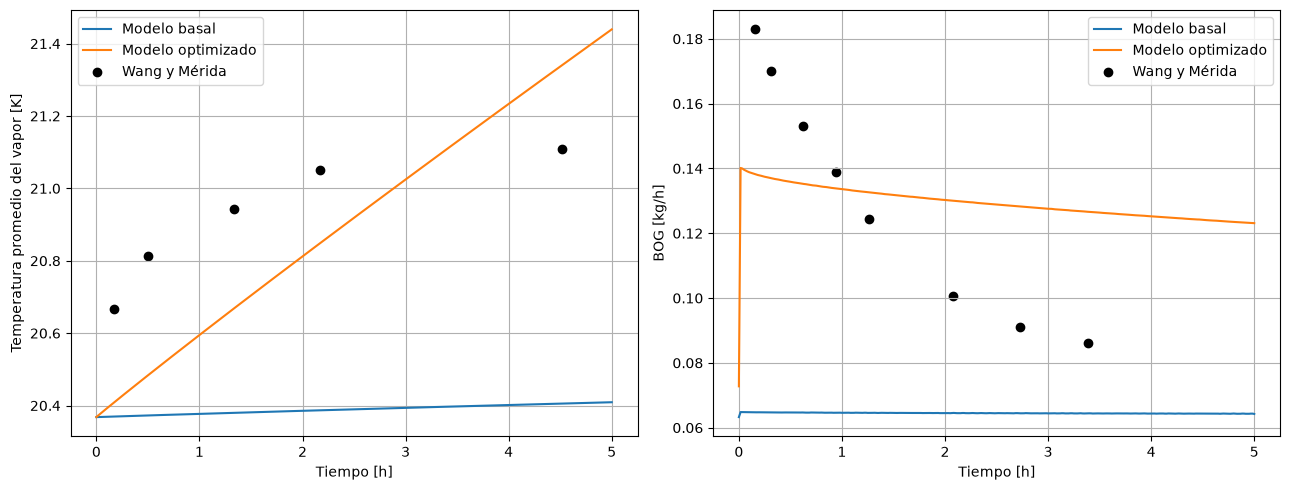

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(model_initial["time_h"], model_initial["Tv_avg_K"], label="Modelo basal")
axes[0].plot(model_optimized["time_h"], model_optimized["Tv_avg_K"], label="Modelo optimizado")
axes[0].scatter(Tv_vertical_exp["time_h"], Tv_vertical_exp["value"], color="black", label="Wang y Mérida")
axes[0].set_xlabel("Tiempo [h]")
axes[0].set_ylabel("Temperatura promedio del vapor [K]")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(model_initial["time_h"], model_initial["BOG_kg_h"], label="Modelo basal")
axes[1].plot(model_optimized["time_h"], model_optimized["BOG_kg_h"], label="Modelo optimizado")
axes[1].scatter(BOG_vertical_exp["time_h"], BOG_vertical_exp["value"], color="black", label="Wang y Mérida")
axes[1].set_xlabel("Tiempo [h]")
axes[1].set_ylabel("BOG [kg/h]")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

### Prueba 2

In [26]:
lower_bounds_constrained = np.array([0.0005, 0.85], dtype=float)
upper_bounds_constrained = np.array([0.0050, 0.99], dtype=float)
theta_start_constrained = np.array([U_initial, 0.95], dtype=float)

evaluation_history_constrained = []

def residuals_for_optimizer_constrained(theta):
    residual_vector = residuals_theta(theta)
    objective_value = float(np.sum(residual_vector**2))

    evaluation_history_constrained.append({"U": theta[0], "eta_w": theta[1], "objective": objective_value})

    print(f"Evaluación {len(evaluation_history_constrained):02d}: U={theta[0]:.10f}, eta_w={theta[1]:.6f}, J={objective_value:.8f}")

    return residual_vector

In [27]:
optimization_result_constrained = least_squares(residuals_for_optimizer_constrained, theta_start_constrained, bounds=(lower_bounds_constrained, upper_bounds_constrained), method=optimizer_config["method"], ftol=optimizer_config["ftol"], xtol=optimizer_config["xtol"], gtol=optimizer_config["gtol"], max_nfev=optimizer_config["max_nfev"], diff_step=optimizer_config["diff_step"], x_scale=np.array([U_initial, 1.0]), verbose=2)

Evaluación 01: U=0.0018671909, eta_w=0.950000, J=16.07399781
Evaluación 02: U=0.0018858629, eta_w=0.950000, J=15.98988078
Evaluación 03: U=0.0018671909, eta_w=0.959500, J=16.35460071
   Iteration     Total nfev        Cost      Cost reduction    Step norm     Optimality   
       0              1         8.0370e+00                                    7.09e+00    
Evaluación 04: U=0.0030690717, eta_w=0.873512, J=9.33947279
Evaluación 05: U=0.0030997624, eta_w=0.873512, J=9.26852282
Evaluación 06: U=0.0030690717, eta_w=0.882247, J=9.63827184
       1              2         4.6697e+00      3.37e+00       7.65e-02       2.27e+00    
Evaluación 07: U=0.0036865663, eta_w=0.854452, J=7.70293206
Evaluación 08: U=0.0037234320, eta_w=0.854452, J=7.67245138
Evaluación 09: U=0.0036865663, eta_w=0.862997, J=7.98461636
       2              3         3.8515e+00      8.18e-01       1.91e-02       5.72e-01    
Evaluación 10: U=0.0039575926, eta_w=0.850420, J=7.42703440
Evaluación 11: U=0.0039971685, et

In [28]:
theta_constrained = optimization_result_constrained.x
objective_constrained = 2.0 * optimization_result_constrained.cost
q_constrained = theta_constrained[0] * (T_air_fixed - base_tank.cryogen.T_sat)

print("\nOptimización físicamente restringida:")
print(f"Éxito                       = {optimization_result_constrained.success}")
print(f"Mensaje                     = {optimization_result_constrained.message}")
print(f"U optimizado                = {theta_constrained[0]:.12f} W/(m² K)")
print(f"eta_w optimizado            = {theta_constrained[1]:.10f}")
print(f"Flux inicial equivalente    = {q_constrained:.10f} W/m²")
print(f"Objetivo restringido        = {objective_constrained:.10f}")
print(f"Objetivo sin restricción    = {objective_optimized:.10f}")
print(f"eta_w en límite inferior    = {np.isclose(theta_constrained[1], lower_bounds_constrained[1], rtol=0.0, atol=1e-5)}")
print(f"eta_w en límite superior    = {np.isclose(theta_constrained[1], upper_bounds_constrained[1], rtol=0.0, atol=1e-5)}")
print(f"U en algún límite           = {np.isclose(theta_constrained[0], lower_bounds_constrained[0], atol=1e-7) or np.isclose(theta_constrained[0], upper_bounds_constrained[0], atol=1e-7)}")


Optimización físicamente restringida:
Éxito                       = True
Mensaje                     = `gtol` termination condition is satisfied.
U optimizado                = 0.004040092153 W/(m² K)
eta_w optimizado            = 0.8500000189
Flux inicial equivalente    = 1.0818636838 W/m²
Objetivo restringido        = 7.4053105757
Objetivo sin restricción    = 3.4661428495
eta_w en límite inferior    = True
eta_w en límite superior    = False
U en algún límite           = False


# Descartado

In [ ]:
def prepare_experimental_curve(
    dataframe,
    time_column,
    value_column,
    time_min_h = 0.0,
    time_max_h = None
):

curve = dataframe [[time_column, value_column]].copy()

curve.columns = ["time_h", "value"]

curve["time_h"] = pd.to_numeric(curve["time_h"], errors = "coerce")
curve["value"] = pd.to_numeric(curve["value"], errors = "coerce")

curve = curve.dropna(subset = ["time_h", "value"])
curve = curve[curve["time_h"] >= time_min_h]

if time_max_h is not None:
    curve = curve[curve["time_h"] <= time_max_h]

curve = curve.sort_values("time_h")

#Tiempos repetidos
curve = curve.groupby("time_h", as_index = False).mean()

curve = curve.reset_index(drop = True)

if curve.empty: 
    raise ValueError("La curva experimental queda vacía")

return curve

### Versión 2

#### Interpola una variable calculada por el modelo en los tiempos donde existen datos experimentales.

Parametros

x_exp : array-like Tiempos experimentales.

x_model : array-like Tiempos entregados por el modelo.

y_model : array-like Valores de la variable simulada en x_model.

Returns

y_model_interpolated : numpy.ndarrayValores del modelo interpolados en x_exp.